#<font color='blue'> **Load Libraries and Dataset**

In [ ]:
#import neccessary libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

There are toy datasets that you can play around with. You can find some datasets from scikit-learn that doesnt require you to download. </br>
https://scikit-learn.org/stable/datasets/toy_dataset.html

In [ ]:
from sklearn.datasets import load_iris

Load the dataset into dataframe to better manipulate any data

In [ ]:
# Load iris dataset directly as a DataFrame
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)

## ☝ <font color = 'Indigo'> **BONUS!** </font> <br>
Iris dataset is not just a dataset. It is a **bunch object**. A bunch, can extend dictionaries by enabling values to be accessed by key.<br>
Using the `.keys()` function, it will show you what's further inside the object. <br>
Let's see the difference of displaying the dataframe vs displaying the bunch.

In [ ]:
#view the dataframe
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [ ]:
#view the dataset keys
print(iris.keys())

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


In [ ]:
# First 5 rows of data (features)
print("Sample of data (features):")
print(pd.DataFrame(iris.data, columns=iris.feature_names).head(), "\n")

Sample of data (features):
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2 



In [ ]:
# First 5 targets (numeric species labels)
print("Sample of target (numeric labels):")
print(iris.target[:5], "\n")

Sample of target (numeric labels):
[0 0 0 0 0] 



In [ ]:
# Target names (species)
print("Target names (species):")
print(iris.target_names, "\n")

Target names (species):
['setosa' 'versicolor' 'virginica'] 



since we already know that the values are in cm, we can shorten the column names.

In [ ]:
df = df.rename(columns={
    'sepal length (cm)': 'sepal_length',
    'sepal width (cm)': 'sepal_width',
    'petal length (cm)': 'petal_length',
    'petal width (cm)': 'petal_width'
})

In [ ]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


Later we will append the target column. For now, let's continue with the correlationship with the feature_names

#<font color='blue'> **Computing the Correlationship**
<p>Using .corr() function allows us to find the pairwise correlation of all (numerical) columns in the dataframe. </br>

**Syntax**: DataFrame.corr(self, method='pearson', min_periods=1, numeric_only = False)

**Parameters:**

<font color = 'green'>method: </font>
- ***pearson***: standard correlation coefficient (this is the default method)
- ***kendall***: Kendall Tau correlation coefficient
- ***spearman***: Spearman rank correlation<br>

<font color = 'green'>min_periods</font>: Minimum number of observations required per pair of columns to have a valid result. Currently only available for pearson and spearman correlation. This parameter is optional<br>
<font color = 'green'>numeric_only:</font> Whether only the numeric values are to be operated upon or not. It is set to False by default.<br>
<p>Returns: count :y : DataFrame

In [ ]:
#passing the values of the correlation to corr variable
corr = df.corr()
corr

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000000,-0.117570,0.871754,0.817941
sepal_width,-0.117570,1.000000,-0.428440,-0.366126
petal_length,0.871754,-0.428440,1.000000,0.962865
petal_width,0.817941,-0.366126,0.962865,1.000000


# **<font color='blue'>Plotting the Correlation</font>**

##<font color='green'> **Heat Map**

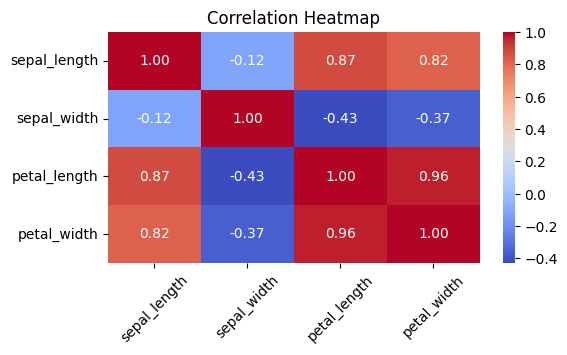

In [ ]:
plt.figure(figsize=(6,3))  # Set figure size
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.title('Correlation Heatmap')
plt.show()

- The correlation between the self is 1.0
- The negative correlation defined negative relationship means on increasing one column value second will decrease and vice-versa.
- The zeros correlation defines no relationship I.e neutral.
- The positive correlations define positive relationships meaning on increasing one column value second will also increase and vice-versa.
- A good correlation depends on the use, but it is safe to say you have at least 0.6 (or -0.6) to call it a good correlation.

##<font color='green'> **Scatter Plot**

Scatter plots are one of the most fundamental and powerful tools for visualizing relationships between two numerical variables.

**Syntax**: matplotlib.pyplot.scatter(x, y, s=None, c=None, marker=None, cmap=None, alpha=None, edgecolors=None, label=None)

**Parameters:**

|  Parameter | Description  |
|---|---|
| x, y | Sequences of data points to plot  |
| s  | Marker size (scalar or array-like)  |
| c  | Marker color  |
| marker   | Shape of the marker  |
| cmap   | Colormap for mapping numeric values to colors  |
| alpha  | Transparency (0 = transparent, 1 = opaque)  |
| edgecolors  | Color of marker edges  |
| label  | Legend label for the dataset  |

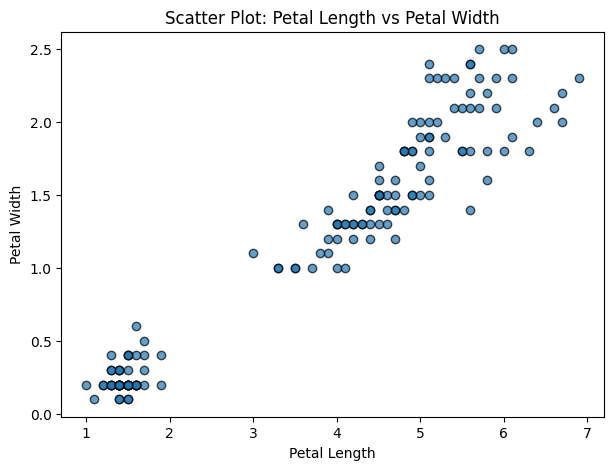

In [ ]:
plt.figure(figsize=(7,5))
plt.scatter(df['petal_length'], df['petal_width'], alpha=0.7, edgecolors='k')
plt.title("Scatter Plot: Petal Length vs Petal Width")
plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.show()

You may also use Seaborn. <br>First, we need to define the target variable. Recall the bunch we discussed earlier? We will use the 'target' to populate the 'species' column that we will add into our dataframe

In [ ]:
df['species'] = iris.target  # add target as species index
df['species'] = df['species'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

❗ Tada! You now have new column 'species'

In [ ]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


Now let's plot!

We can add a regression line to be able to see the correlation clearly.<br>
With seaborn, we can be able to use:
- sns.regplot() for one trend line
- sns.lmplot() for per-species trend lines

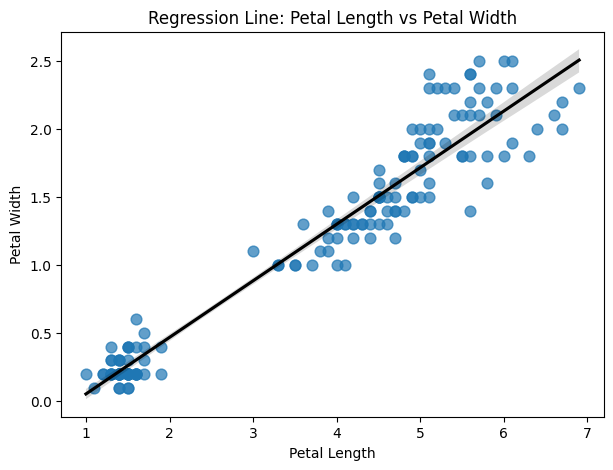

In [ ]:
# one overall regression line
plt.figure(figsize=(7,5))
sns.regplot(
    data=df,
    x='petal_length',
    y='petal_width',
    scatter_kws={'s': 60, 'alpha':0.7},   # style for points
    line_kws={'color':'black'}            # style for trend line
)
plt.title("Regression Line: Petal Length vs Petal Width")
plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.show()

What can we observe from the graph?

Now, we'll try to put different colors to classify each specie.

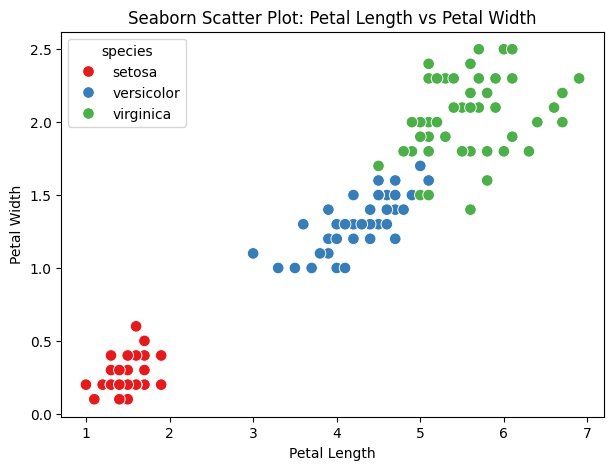

In [ ]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    data=df,
    x='petal_length',
    y='petal_width',
    hue='species',   # color by species
    palette='Set1',
    s=70
)
plt.title("Seaborn Scatter Plot: Petal Length vs Petal Width")
plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.show()

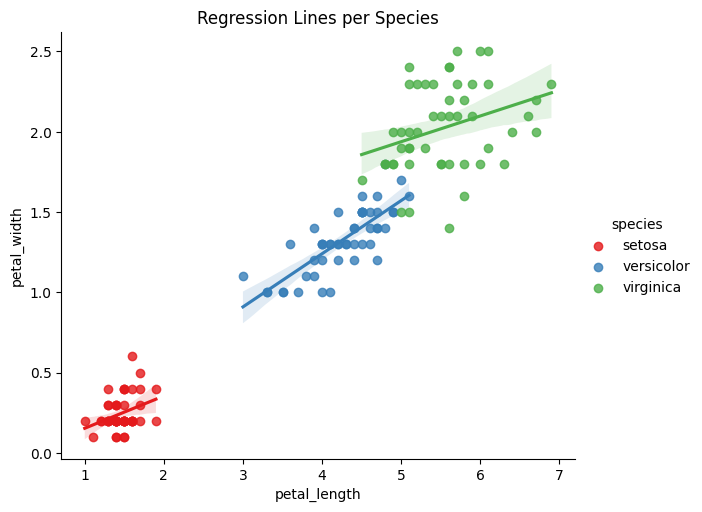

In [ ]:
# regression line per specie
sns.lmplot(
    data=df,
    x='petal_length',
    y='petal_width',
    hue='species',
    palette='Set1',
    height=5,
    aspect=1.2
)
plt.title("Regression Lines per Species")
plt.show()

From previous diagram, we see that as the length increases, so does the width. Hence, there is a positive correlation. However, when we broken down into detail, we see that:
- Setosa (red) → flat, tiny slope (petal length and width don’t vary much).
- Versicolor (blue) → clear upward slope, moderate correlation.
- Virginica (green) → also upward slope, strong correlation.

Notice the shaded area around each line? That is the confidence interval (the uncertainty of the regression fit). <font color='green'> **By default, seaborn shows 95% CI**</font> around the regression line. <br>
**How to interpret the band?**
- Narrow band means that regression line is estimated with high precision (strong, consistent relationship).
- Wide band means more uncertainty (data points are more spread out, weaker relationship).


Note, however, that CI is not about the spread of the data points within the line, but the uncertainty in the line.

CI width depends on:
- Sample size (more data = narrower CI).
- Variability (less scatter = narrower CI).
- Confidence level chosen (99% CI would be wider than 95%).

Let's explore different CI!

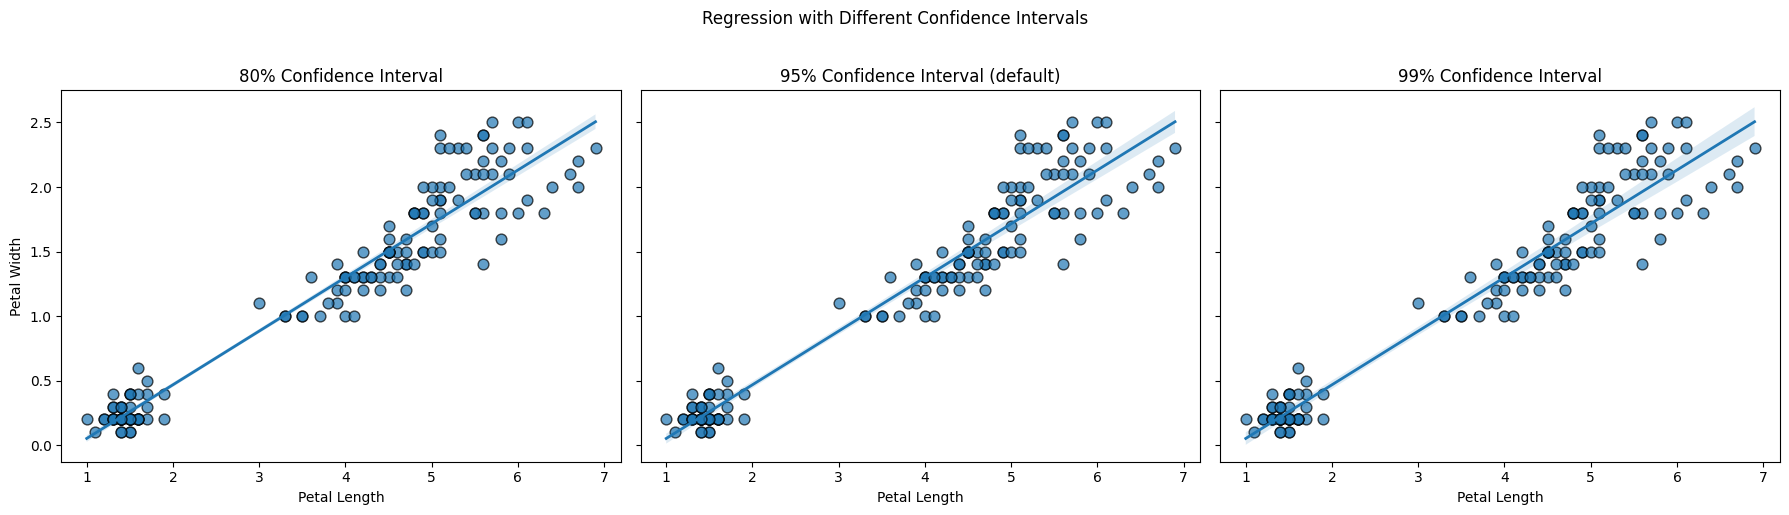

In [ ]:
plt.close('all')

cis = [80, 95, 99]
titles = ["80% Confidence Interval", "95% Confidence Interval (default)", "99% Confidence Interval"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, ci, title in zip(axes, cis, titles):
    sns.regplot(
        data=df,
        x="petal_length",
        y="petal_width",
        ci=ci,
        scatter_kws={'s': 60, 'alpha': 0.7, 'edgecolor': 'k'},
        line_kws={'linewidth': 2},
        ax=ax
    )
    ax.set_title(title)
    ax.set_xlabel("Petal Length")
    ax.set_ylabel("Petal Width" if ax is axes[0] else "")

plt.suptitle("Regression with Different Confidence Intervals", y=1.02)
plt.tight_layout()
plt.show()

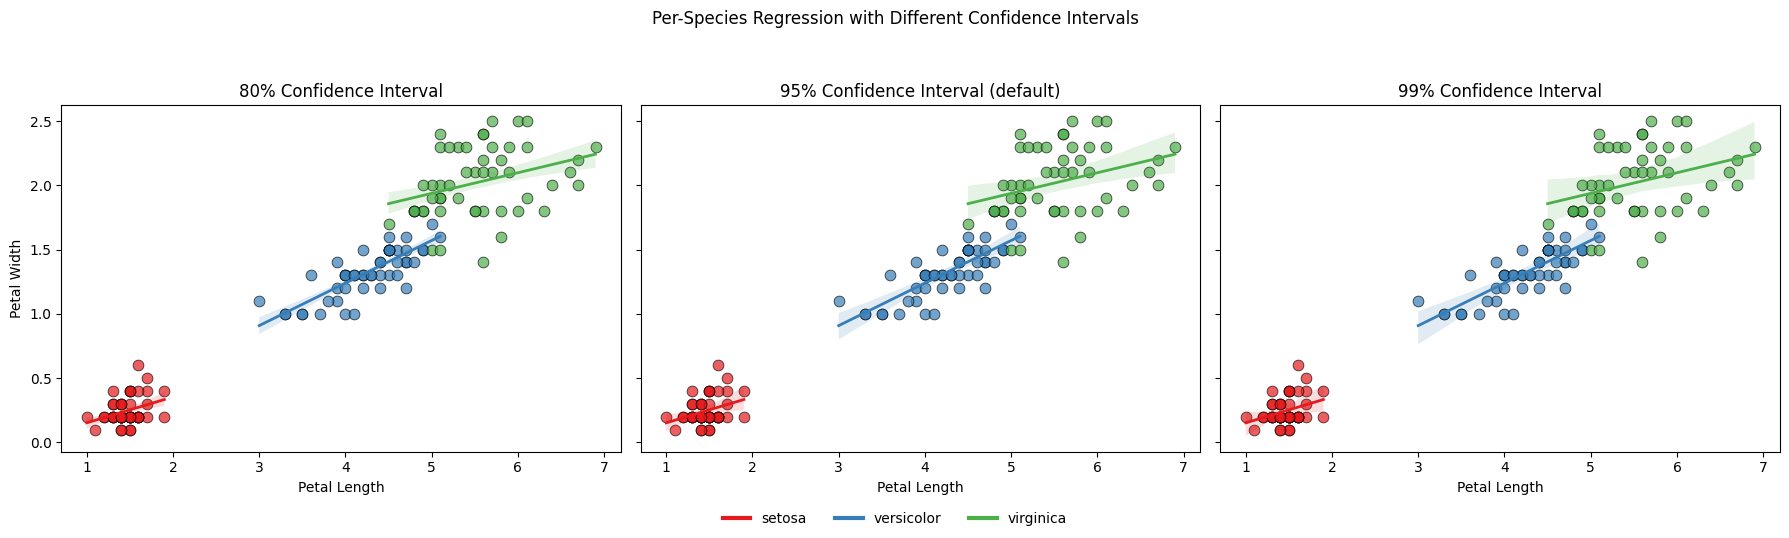

In [ ]:
from matplotlib.lines import Line2D

species = {"setosa": 80, "versicolor": 95, "virginica": 99}
palette = dict(zip(species, sns.color_palette('Set1', 3)))
fig, axes = plt.subplots(1, 3, figsize=(18,5), sharey=True)

plt.close('all')
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, ci, title in zip(axes, cis, titles):
    # scatter + regression per species
    for sp in species:
        sub = df[df['species'] == sp]
        sns.scatterplot(
            data=sub, x="petal_length", y="petal_width",
            color=palette[sp], alpha=0.7, s=60, edgecolor='k', ax=ax
        )
        sns.regplot(
            data=sub, x="petal_length", y="petal_width",
            ci=ci, scatter=False, color=palette[sp],
            line_kws={'linewidth': 2}, ax=ax
        )
    ax.set_title(title)
    ax.set_xlabel("Petal Length")
    ax.set_ylabel("Petal Width" if ax is axes[0] else "")

# display legend
handles = [Line2D([0],[0], color=palette[sp], lw=3, label=sp) for sp in species]
fig.legend(handles=handles, labels=species, loc="lower center", ncol=3, frameon=False)

plt.suptitle("Per-Species Regression with Different Confidence Intervals", y=1.05)
plt.tight_layout(rect=[0,0.05,1,1])  # legend space
plt.show()

THIS IS AN EDIT. Testing github.123